# House Price Prediction 
In this project i used a dataset of Kaggle to do a predictive analysis of house price. 

This project is separeted in ? parts:

1. Business Problem; 
2. Collect the Data and understand it;
3. Split the data in train and test;
4. EDA;
5. Data Cleaning and preprocessing;
6. Model training, comparison, selectioon and tuning;
7. training final model and test. 
8. App



## 01  Business Problem

Accurately estimating house prices is a major challenge in the real estate market, since property values are influenced by many different factors beyond basic characteristics such as the number of bedrooms or the size of the house.

In this project, the goal is to develop a machine learning model capable of predicting residential property prices in Ames, Iowa, using a dataset containing 79 explanatory variables that describe nearly every aspect of a house.

The dataset includes information related to:
- property size
- construction quality
- neighborhood
- garage characteristics
- basement features
- location-related factors
- and many other residential attributes

Through exploratory data analysis (EDA), data preprocessing, and regression modeling, this project aims to identify the factors that most influence house prices and generate accurate predictions for unseen properties.

The final objective is to build a predictive model that can support better pricing decisions in the real estate market while also demonstrating practical applications of data analysis and machine learning techniques.

## 02 Collect the data and understand it

Let's import the libraries.

In [54]:
# data manipulation and visualization
import pandas as pd 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler
)
from sklearn.model_selection import KFold, cross_val_score,GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Lasso, ElasticNet
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# visualization settings 
%matplotlib inline
mpl.style.use('ggplot')
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['xtick.color'] ='black'
mpl.rcParams['ytick.color'] ='black'
mpl.rcParams['grid.color'] = 'lightgray'
mpl.rcParams['axes.grid'] = True
mpl.rcParams['font.size'] = 12

# Usefull functions
import sys
sys.path.append("../src")
from utilities import plot_numeric_distribution
from utilities import check_outliers
from utilities import plot_boxplot
from utilities import plot_scatter_vs_target
from utilities import plot_categorical_distribution
from utilities import plot_categorical
from utilities import plot_boxplot_target
from utilities import high_correlation_pairs
from utilities import compare_models
from utilities import plot_model_comparison

# Machine Learning
from sklearn.model_selection import train_test_split
# Palettes Setting
custom_palette = [
    "#606C38",  # verde musgo
    "#DDA15E",  # bege quente
    "#FEFAE0",  # creme
    "#BC6C25",  # marrom terroso
    "#283618"   # verde escuro
]

sns.set_palette(custom_palette)
sns.color_palette(custom_palette)



[(0.3764705882352941, 0.4235294117647059, 0.2196078431372549),
 (0.8666666666666667, 0.6313725490196078, 0.3686274509803922),
 (0.996078431372549, 0.9803921568627451, 0.8784313725490196),
 (0.7372549019607844, 0.4235294117647059, 0.1450980392156863),
 (0.1568627450980392, 0.21176470588235294, 0.09411764705882353)]

### Undestanding the data 
I used a dataset from Kagllen it can be found in:

https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

Let's load the data and take a view at it.


In [3]:
df=pd.read_csv('../data/train.csv')      
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# let's see the shape of the data
print(f"Dataset shape: {df.shape}")

Dataset shape: (1460, 81)


The data have so much columns. In this analisys we will focus on just some columns. 

In [5]:
columns=['SalePrice',
        'OverallQual',
        'GrLivArea',
        'GarageCars',
        'GarageArea',
        'TotalBsmtSF',
        '1stFlrSF',
        'FullBath',
        'TotRmsAbvGrd',
        'YearBuilt',
        'YearRemodAdd',
        'Neighborhood',
        'SaleCondition',
        'MSZoning',
        'LotShape',
        'LotArea',
        'Utilities',
        'BedroomAbvGr',
        'KitchenAbvGr',]


df=df[columns]

In [6]:
# Let's see datas infortmations 
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   SalePrice      1460 non-null   int64
 1   OverallQual    1460 non-null   int64
 2   GrLivArea      1460 non-null   int64
 3   GarageCars     1460 non-null   int64
 4   GarageArea     1460 non-null   int64
 5   TotalBsmtSF    1460 non-null   int64
 6   1stFlrSF       1460 non-null   int64
 7   FullBath       1460 non-null   int64
 8   TotRmsAbvGrd   1460 non-null   int64
 9   YearBuilt      1460 non-null   int64
 10  YearRemodAdd   1460 non-null   int64
 11  Neighborhood   1460 non-null   str  
 12  SaleCondition  1460 non-null   str  
 13  MSZoning       1460 non-null   str  
 14  LotShape       1460 non-null   str  
 15  LotArea        1460 non-null   int64
 16  Utilities      1460 non-null   str  
 17  BedroomAbvGr   1460 non-null   int64
 18  KitchenAbvGr   1460 non-null   int64
dtypes: int64(14), str

(1460, 19)

In [7]:
# Let's take a look in the head
df.head()

,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,Neighborhood,SaleCondition,MSZoning,LotShape,LotArea,Utilities,BedroomAbvGr,KitchenAbvGr
0,208500,7,1710,2,548,856,856,2,8,2003,2003,CollgCr,Normal,RL,Reg,8450,AllPub,3,1
1,181500,6,1262,2,460,1262,1262,2,6,1976,1976,Veenker,Normal,RL,Reg,9600,AllPub,3,1
2,223500,7,1786,2,608,920,920,2,6,2001,2002,CollgCr,Normal,RL,IR1,11250,AllPub,3,1
3,140000,7,1717,3,642,756,961,1,7,1915,1970,Crawfor,Abnorml,RL,IR1,9550,AllPub,3,1
4,250000,8,2198,3,836,1145,1145,2,9,2000,2000,NoRidge,Normal,RL,IR1,14260,AllPub,4,1


### Data Dictionary
- **SalePrice**: price that the house was saled.
- **OverallQual**: Rates the overall material and finish of the house

       10	Very Excellent
       9	Excellent
       8	Very Good
       7	Good
       6	Above Average
       5	Average
       4	Below Average
       3	Fair
       2	Poor
       1	Very Poor
- **GrLivArea**: Above grade (ground) living area square feet

        BsmtFullBath: Basement full bathrooms

        BsmtHalfBath: Basement half bathrooms

        FullBath: Full bathrooms above grade

        HalfBath: Half baths above grade
- **GarageCars**: Size of garage in car capacity
- **GarageArea**: Size of garage in square feet
- **TotalBsmtSF**: Total square feet of basement area
- **1stFlrSF**: First Floor square feet
- **FullBath**: Full bathrooms above grade
- **TotRmsAbvGrd**: Total rooms above grade (does not include bathrooms)
- **YearBuilt**: Original construction date
- **YearRemodAdd**: Remodel date (same as construction date if no remodeling or additions)
- **Neighborhood**: Physical locations within Ames city limits

       Blmngtn	Bloomington Heights
       Blueste	Bluestem
       BrDale	Briardale
       BrkSide	Brookside
       ClearCr	Clear Creek
       CollgCr	College Creek
       Crawfor	Crawford
       Edwards	Edwards
       Gilbert	Gilbert
       IDOTRR	Iowa DOT and Rail Road
       MeadowV	Meadow Village
       Mitchel	Mitchell
       Names	North Ames
       NoRidge	Northridge
       NPkVill	Northpark Villa
       NridgHt	Northridge Heights
       NWAmes	Northwest Ames
       OldTown	Old Town
       SWISU	South & West of Iowa State University
       Sawyer	Sawyer
       SawyerW	Sawyer West
       Somerst	Somerset
       StoneBr	Stone Brook
       Timber	Timberland
       Veenker	Veenker
- **SaleCondition**: Condition of sale


       Normal	Normal Sale
       Abnorml	Abnormal Sale -  trade, foreclosure, short sale
       AdjLand	Adjoining Land Purchase
       Alloca	Allocation - two linked properties with separate deeds, typically condo with a garage unit	
       Family	Sale between family members
       Partial	Home was not completed when last assessed (associated with New Homes)
- **MSZoning**: Identifies the general zoning classification of the sale.
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM	Residential Medium Density
- **LotShape**: General shape of property

       Reg	Regular	
       IR1	Slightly irregular
       IR2	Moderately Irregular
       IR3	Irregular
- **LotArea**: Lot size in square feet
- **Utilities**: Type of utilities available
		
       AllPub	All public Utilities (E,G,W,& S)	
       NoSewr	Electricity, Gas, and Water (Septic Tank)
       NoSeWa	Electricity and Gas Only
       ELO	Electricity only
- **Bedroom**: Bedrooms above grade (does NOT include basement bedrooms)
- **Kitchen**:Kitchens above grade



Let's look for null values and duplicates


In [8]:
df.isnull().sum()


SalePrice        0
OverallQual      0
GrLivArea        0
GarageCars       0
GarageArea       0
TotalBsmtSF      0
1stFlrSF         0
FullBath         0
TotRmsAbvGrd     0
YearBuilt        0
YearRemodAdd     0
Neighborhood     0
SaleCondition    0
MSZoning         0
LotShape         0
LotArea          0
Utilities        0
BedroomAbvGr     0
KitchenAbvGr     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

No null values and no duplicates.

## 03 Split into train and test 
I will split the data into a train set and a test set. The test set should be a set of data that the model has never seen before. I will perform EDA on the training set, to avoid data leakage.

In [10]:
X=df.drop('SalePrice', axis=1)
Y=df['SalePrice']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)    

In [11]:
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (1168, 18)
Y_train shape: (1168,)
X_test shape: (292, 18)
Y_test shape: (292,)


## 04 Exploratory Data Analysis
We will explore the training set in order to see how the features are individually ditributed, the relashionships between them, and get possible insights from the datas. 

In [12]:
train = pd.concat([X_train, Y_train], axis=1)
test = pd.concat([X_test, Y_test], axis=1)
train.head()

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,Neighborhood,SaleCondition,MSZoning,LotShape,LotArea,Utilities,BedroomAbvGr,KitchenAbvGr,SalePrice
254,5,1314,1,294,1314,1314,1,5,1957,1957,NAmes,Normal,RL,Reg,8400,AllPub,3,1,145000
1066,6,1571,2,380,799,799,2,7,1993,1994,Gilbert,Normal,RL,IR1,7837,AllPub,3,1,178000
638,5,796,0,0,796,796,1,4,1910,1950,Edwards,Normal,RL,Reg,8777,AllPub,2,1,85000
799,5,1768,1,240,731,981,1,7,1937,1950,SWISU,Normal,RL,Reg,7200,AllPub,3,1,175000
380,5,1691,1,308,1026,1026,2,6,1924,1950,SWISU,Normal,RL,Reg,5000,AllPub,3,1,127000


Let's take a look in the numerical and categorical features.


In [13]:
numerical_features = train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = train.select_dtypes(include=['object', 'str']).columns
target = 'SalePrice'

print(f'There are {len(numerical_features)} numerical features, they are: {numerical_features.tolist()}')
print(f'\nThere are {len(categorical_features)} categorical features, they are: {categorical_features.tolist()}')
print(f'\nThe target variable is: {target}')


There are 14 numerical features, they are: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'LotArea', 'BedroomAbvGr', 'KitchenAbvGr', 'SalePrice']

There are 5 categorical features, they are: ['Neighborhood', 'SaleCondition', 'MSZoning', 'LotShape', 'Utilities']

The target variable is: SalePrice


Now i'll take a look in the categorical columns.

In [14]:
for col in categorical_features:
    print(col)
    print('-'*40)
    print(f'Ther are {train[col].nunique()} unique values. They are: ')
    print(train[col].value_counts(normalize=True) )
    print()

Neighborhood
----------------------------------------
Ther are 25 unique values. They are: 
Neighborhood
NAmes      0.154966
CollgCr    0.098459
OldTown    0.077911
Edwards    0.074486
Somerst    0.059075
NWAmes     0.056507
Gilbert    0.055651
NridgHt    0.052226
Sawyer     0.049658
BrkSide    0.038527
Crawfor    0.037671
SawyerW    0.037671
Mitchel    0.034247
NoRidge    0.028253
Timber     0.023973
IDOTRR     0.022260
SWISU      0.017979
StoneBr    0.017123
ClearCr    0.016267
Blmngtn    0.012842
BrDale     0.011130
MeadowV    0.008562
Veenker    0.007705
NPkVill    0.005993
Blueste    0.000856
Name: proportion, dtype: float64

SaleCondition
----------------------------------------
Ther are 6 unique values. They are: 
SaleCondition
Normal     0.825342
Partial    0.083904
Abnorml    0.065925
Family     0.015411
Alloca     0.005993
AdjLand    0.003425
Name: proportion, dtype: float64

MSZoning
----------------------------------------
Ther are 5 unique values. They are: 
MSZoning
RL   

## Neighborhood

The `Neighborhood` variable contains 25 unique categories representing different physical locations within Ames city limits.

The distribution shows that some neighborhoods are significantly more common than others:

- `NAmes` represents approximately 15.5% of the dataset
- `CollgCr` represents approximately 9.8%
- `OldTown` represents approximately 7.8%

Additionally, some categories are extremely rare, such as:
- `Blueste` (0.08%)
- `NPkVill` (0.6%)

This suggests that location is likely an important factor influencing house prices, while also indicating the presence of imbalanced categories.

### Encoding Choice

**One Hot Encoding** was selected for `Neighborhood`.

This decision was made because neighborhoods are nominal categories without any natural ordinal relationship. Assigning numerical labels could incorrectly introduce artificial hierarchy between locations.

One Hot Encoding preserves category independence and allows the model to learn location-specific price patterns more effectively.

---

## SaleCondition

The `SaleCondition` variable contains 6 categories describing the condition of the sale.

Most observations belong to the `Normal` category:

- `Normal` accounts for approximately 82.5% of all sales

The remaining categories have considerably lower frequencies, indicating a highly imbalanced distribution.

### Encoding Choice

**One Hot Encoding** was selected for `SaleCondition`.

Since sale conditions do not possess an inherent ranking or progression, One Hot Encoding avoids creating false ordinal relationships between categories while preserving categorical information.

---

## MSZoning

The `MSZoning` variable contains 5 zoning classifications.

The dataset is strongly dominated by the `RL` category:

- `RL` represents approximately 79% of the observations

This indicates that most properties belong to low-density residential areas.

### Encoding Choice

**One Hot Encoding** was selected for `MSZoning`.

Zoning classifications represent nominal urban categories without numerical order. Therefore, One Hot Encoding is the most appropriate technique to avoid introducing artificial ranking between zoning types.

---

## LotShape

The `LotShape` variable contains 4 categories describing the general shape of the property.

Most properties have regular shapes:

- `Reg` accounts for approximately 62.4% of observations
- `IR1` accounts for approximately 33.7%

The remaining irregular categories are less frequent.

Unlike the previous variables, `LotShape` presents a natural progression of irregularity:

- `Reg` → Regular
- `IR1` → Slightly Irregular
- `IR2` → Moderately Irregular
- `IR3` → Highly Irregular

### Encoding Choice

**Ordinal Encoding** was selected for `LotShape`.

Because the categories possess a meaningful order, ordinal encoding allows the model to capture increasing levels of lot irregularity numerically, potentially improving predictive performance.

---

## Utilities

The `Utilities` variable contains only two categories.

However, the distribution shows extremely low variability:

- `AllPub` represents more than 99.9% of all observations

This indicates that the variable provides little useful information for prediction.

In [15]:
train.drop(columns='Utilities', inplace=True)

Let's see the target values.


In [16]:
train['SalePrice'].describe()

count      1168.000000
mean     181441.541952
std       77263.583862
min       34900.000000
25%      130000.000000
50%      165000.000000
75%      214925.000000
max      745000.000000
Name: SalePrice, dtype: float64

The target variable `SalePrice` represents the final sale price of residential properties in dollars.

Based on the descriptive statistics, the dataset shows considerable variability in house prices:

- The average sale price is approximately **$181,442**
- The median sale price is **$165,000**
- The standard deviation is approximately **$77,264**

The difference between the mean and median suggests the presence of higher-priced properties pulling the average upward, indicating a possible right-skewed distribution.

The dataset also contains a wide price range:

- Minimum price: **$34,900**
- Maximum price: **$745,000**

This large range indicates substantial diversity in property values, which is expected in real estate datasets containing houses with different sizes, qualities, locations, and conditions.

Additionally:

- 25% of houses were sold below approximately **$130,000**
- 75% of houses were sold below approximately **$214,925**

These quartiles suggest that most properties are concentrated in the mid-price range, while a smaller number of high-value properties may act as outliers.

### Key Insights

- `SalePrice` presents high variability across observations
- The distribution likely contains high-price outliers
- The target variable may be positively skewed
- Feature engineering and outlier analysis may improve model performance
- Applying transformations such as logarithmic scaling could potentially improve regression results

To continue the analysis i will create a column to separate the Sales Price in categories. 

In [17]:
# creating a cut for the target variable to analyze the distribution of the target variable
train["PriceCategory"] = pd.cut(
    train["SalePrice"],
    bins=[0, 130000, 215000, 800000],
    labels=["Low", "Mid", "High"]
)

### Univariate Analysis

Let's start the Univariate Analysis. First, we gonna see our target distribuction.

### Target distribuction 


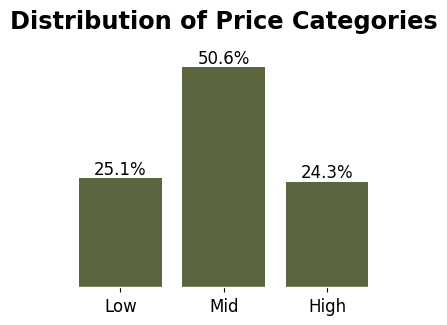

In [18]:
plt.figure(figsize=(4,3))
ax=sns.countplot(data=train, x='PriceCategory')
ax.set_title('Distribution of Price Categories',fontweight='bold', pad=20)
ax.grid(False)
ax.set_xticks(range(3),['Low', 'Mid', 'High'])   
ax.set_xlabel('') 
ax.yaxis.set_visible(False)

total=len(train)
counts=[count.get_height() for count in ax.patches]
percentages=[(count/total)*100 for count in counts]

for count, percentage in zip(ax.patches, percentages):
    x = count.get_x() + count.get_width() / 2
    y = count.get_height()
    ax.annotate(f'{percentage:.1f}%', (x, y), ha='center', va='bottom')

plt.show()

The distribution of property price categories shows that most houses belong to the **Mid-price segment**, representing approximately **50.6%** of the dataset.

Meanwhile:

- **25.1%** of the houses belong to the **Low-price category**
- **24.3%** belong to the **High-price category**

This distribution indicates that the dataset is relatively balanced between lower and higher-priced properties, while the majority of observations are concentrated in the middle market segment.

### Key Insights

- The housing market in the dataset is predominantly composed of mid-range properties.
- Low and high-priced houses appear in similar proportions, suggesting a balanced representation of cheaper and more expensive homes.
- The larger concentration of mid-priced houses may help the model learn more stable pricing patterns for average residential properties.
- Premium or luxury houses are less frequent, which may make extreme price predictions more challenging.
- Segmenting prices into categories improves exploratory analysis by making market patterns easier to visualize and interpret.

### Potential Business Interpretation

The dataset appears to represent a market primarily focused on middle-income residential properties, with smaller portions of entry-level and premium homes. This segmentation can help identify how property characteristics differ across price ranges and support more targeted market analysis.

### Numerical features distributions 
I will see the distribution of numerical features.


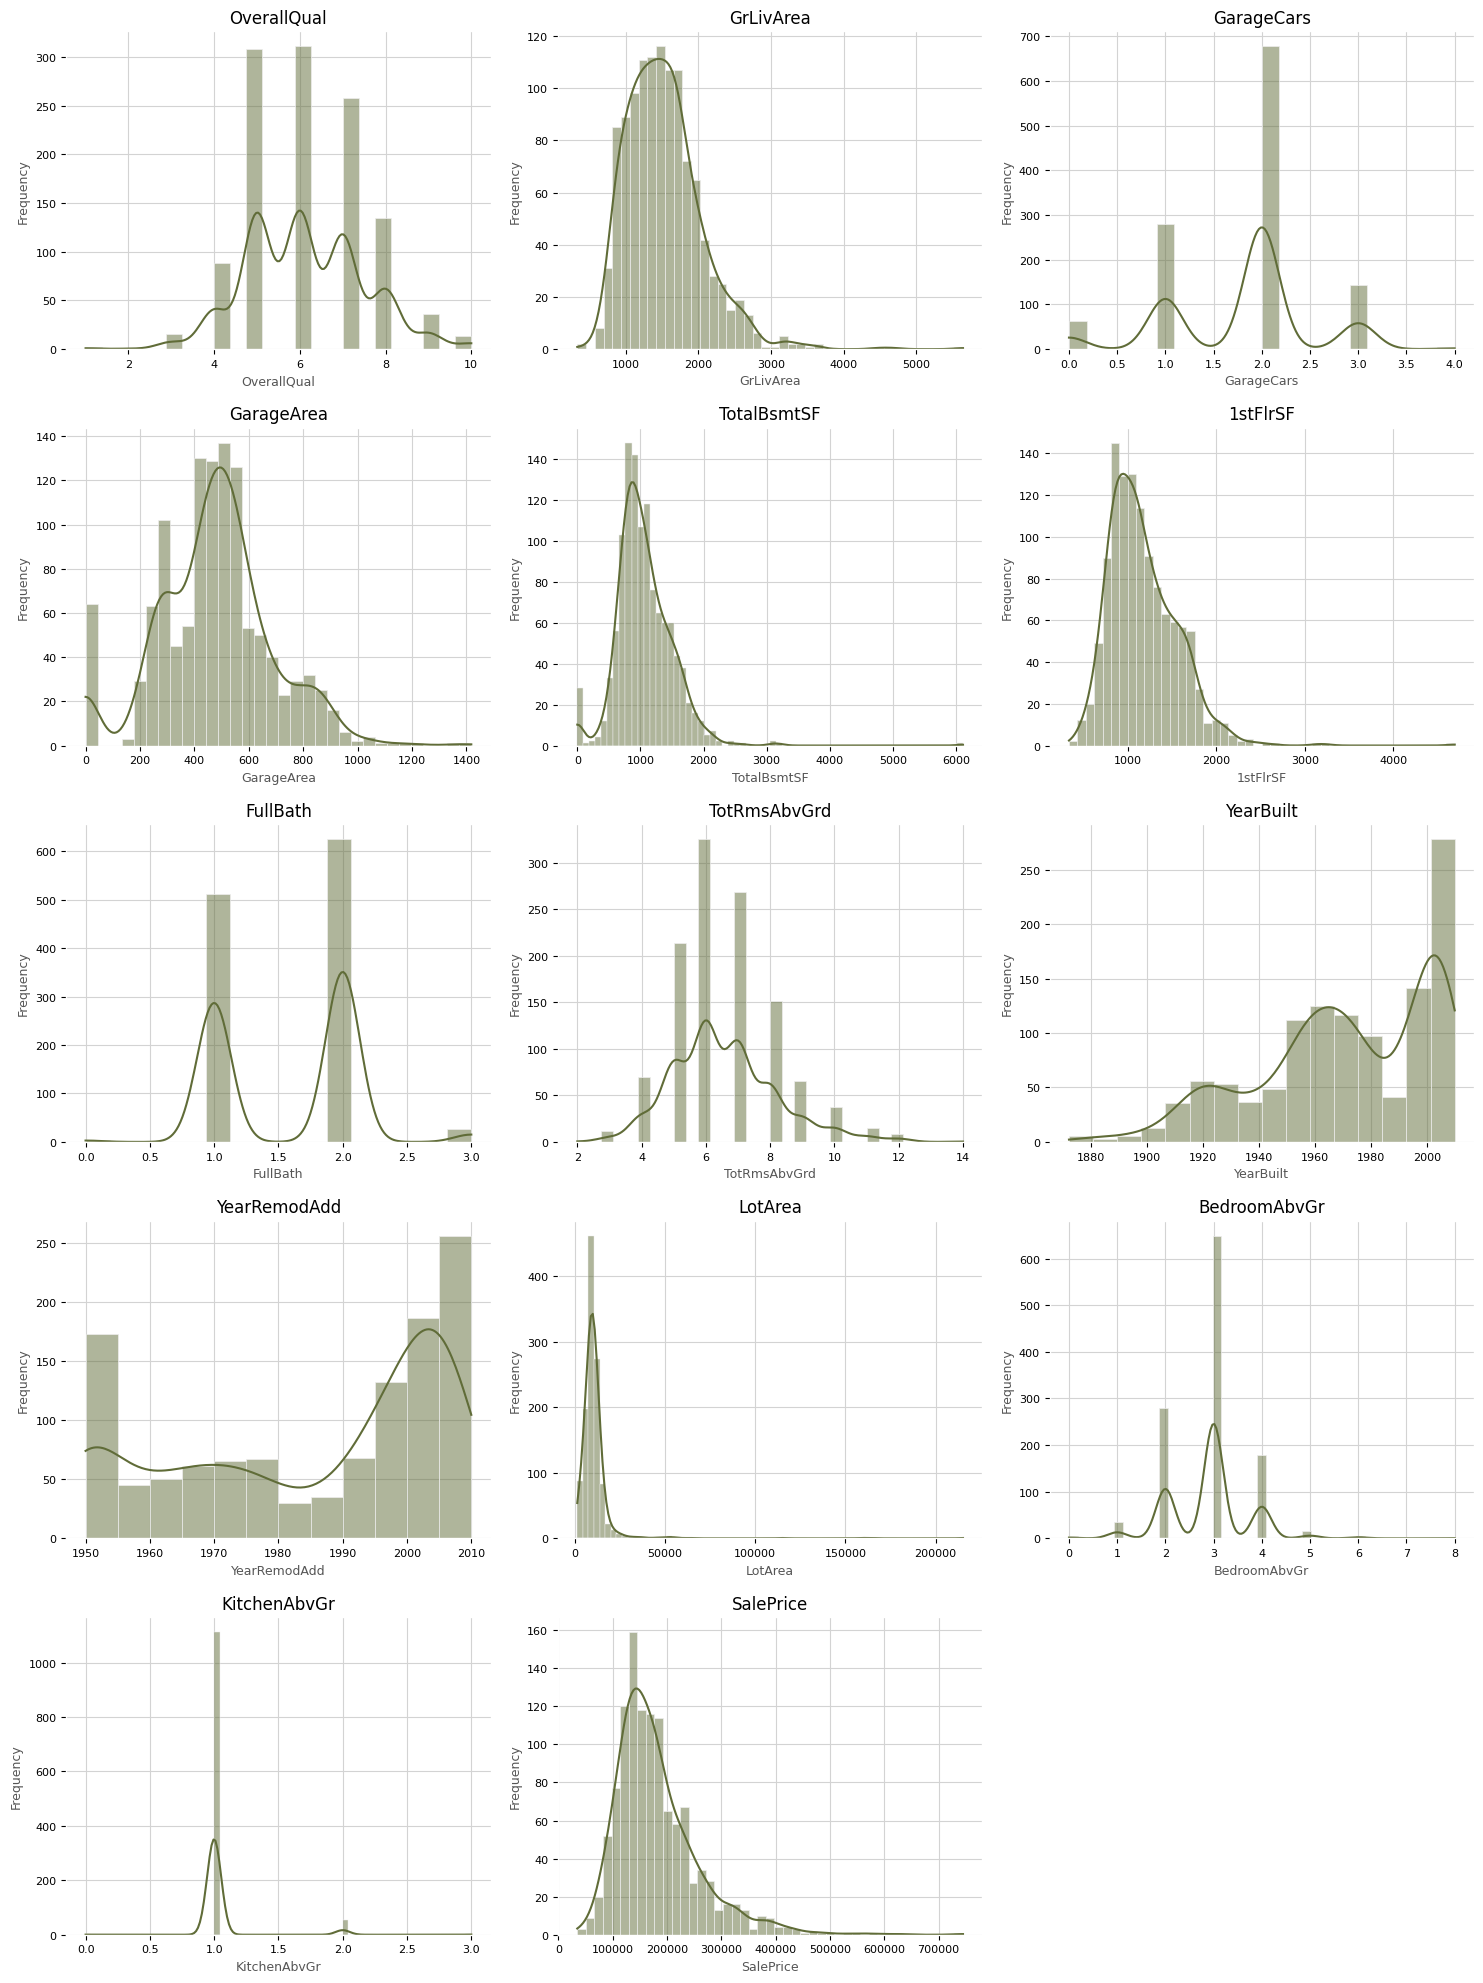

In [19]:
plot_numeric_distribution(train, numerical_features.tolist())


# Main Insights from Numerical Features

The numerical feature distributions reveal several important patterns about the housing market and property prices.

- Most properties have **average to above-average quality**, with `OverallQual` concentrated between ratings 5 and 7.
- The majority of homes have **moderate living areas**, generally between 1,000 and 2,000 square feet.
- Most houses contain:
  - **2 garage spaces**
  - **2 full bathrooms**
  - **3 bedrooms**
  - **5 to 8 total rooms above ground**

These patterns suggest that the dataset is primarily composed of medium-sized family homes.

---

### Skewness and Outliers

Several variables show strong positive skewness, including:

- `SalePrice`
- `LotArea`
- `GrLivArea`
- `TotalBsmtSF`

This indicates the presence of a smaller number of luxury or unusually large properties that create long right tails in the distributions.

The target variable `SalePrice` is also positively skewed, suggesting that:
- most houses belong to lower or middle price ranges
- a few expensive homes act as outliers



---

### Property Age and Renovation

The variables `YearBuilt` and `YearRemodAdd` show a higher concentration of homes built or remodeled after 1950, especially near the 2000s.

This suggests:
- the dataset is dominated by relatively modern homes
- recent renovations may positively impact property prices

---

### Overall Conclusion

The dataset appears to represent a market dominated by mid-range residential properties, while also containing a smaller number of premium or luxury homes.

Features related to:
- quality
- living area
- garage size
- number of rooms
- bathrooms
- construction year

are likely to be strong predictors of house prices.

##  Outliers
Now i'll take a look to the outliers.


In [20]:
check_outliers(train, numerical_features.tolist())

There are 321 outliers in the dataset.
----------------------------------------
OverallQual: 2 outliers, which is 0.17% of the data.
GrLivArea: 23 outliers, which is 1.97% of the data.
GarageCars: 4 outliers, which is 0.34% of the data.
GarageArea: 18 outliers, which is 1.54% of the data.
TotalBsmtSF: 47 outliers, which is 4.02% of the data.
1stFlrSF: 13 outliers, which is 1.11% of the data.
FullBath: 0 outliers, which is 0.00% of the data.
TotRmsAbvGrd: 25 outliers, which is 2.14% of the data.
YearBuilt: 5 outliers, which is 0.43% of the data.
YearRemodAdd: 0 outliers, which is 0.00% of the data.
LotArea: 54 outliers, which is 4.62% of the data.
BedroomAbvGr: 26 outliers, which is 2.23% of the data.
KitchenAbvGr: 56 outliers, which is 4.79% of the data.
SalePrice: 48 outliers, which is 4.11% of the data.


The datas with more outliers are KitchenAbvGr, LotArea, SalePrice, and TotalBsmtSF. Let's make boxplots to explore more about this datas. 


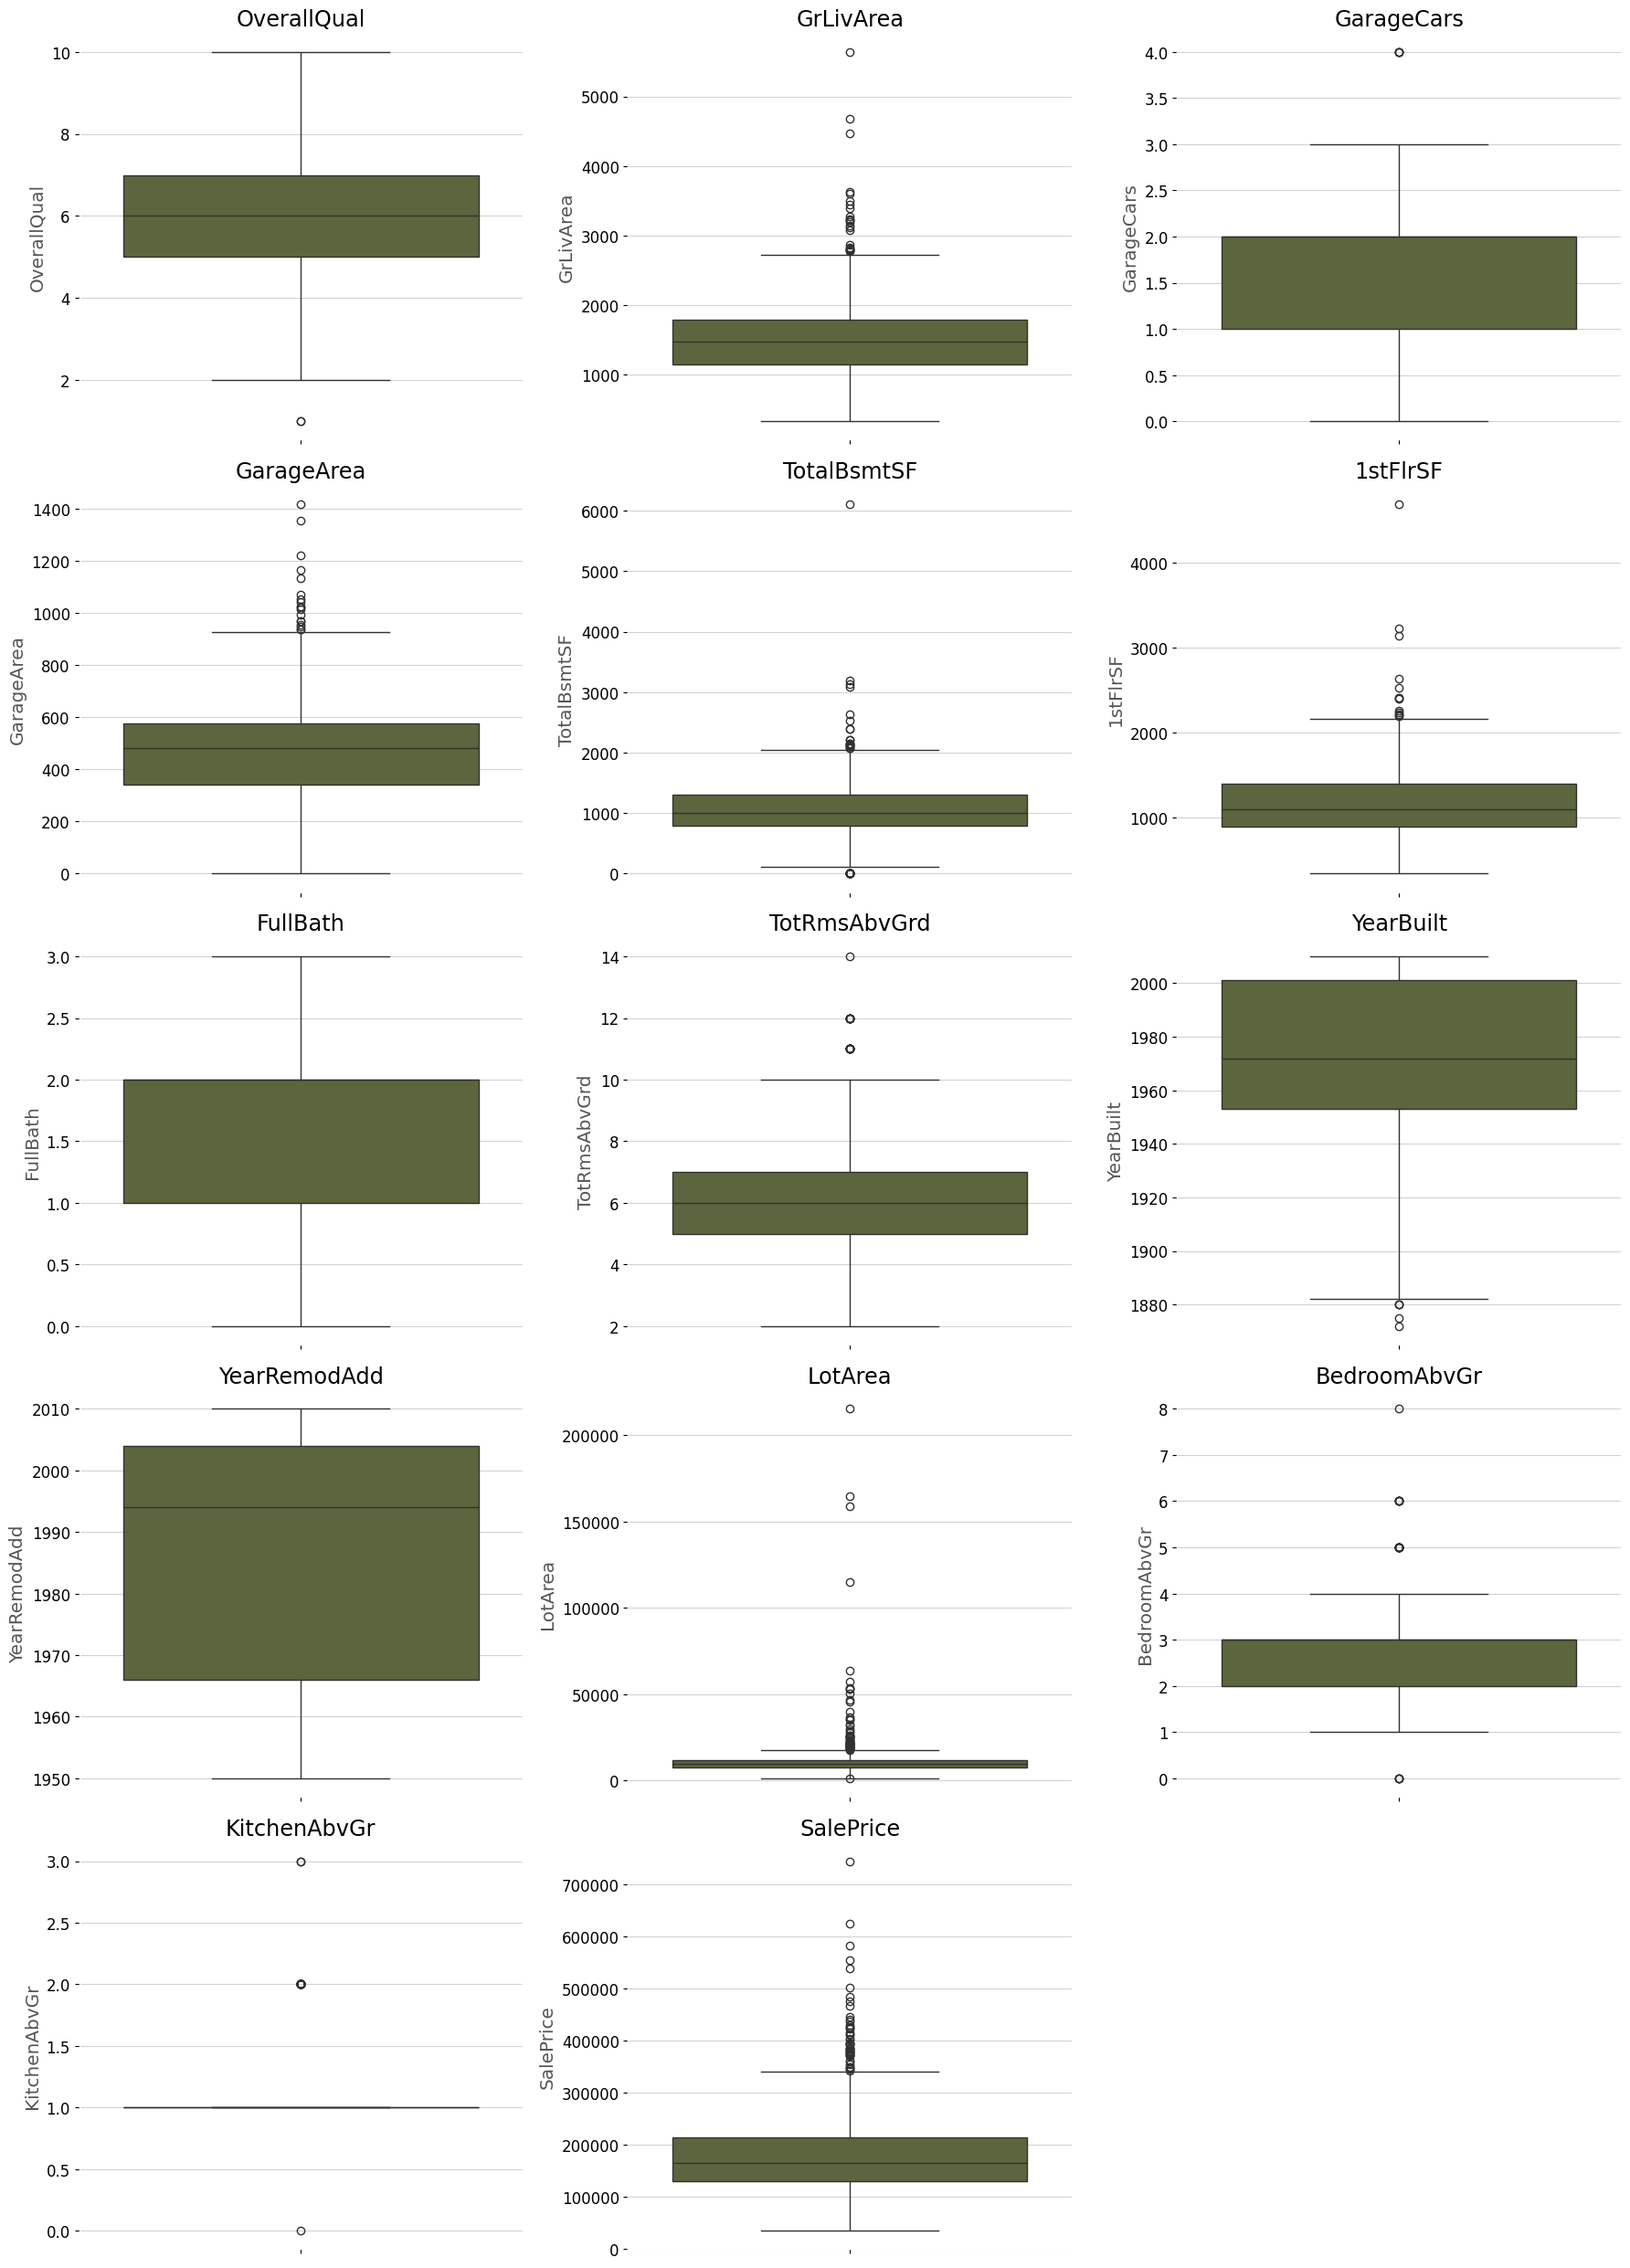

In [21]:
plot_boxplot(train, numerical_features.tolist())

As we can see, there very asymmetrical variables, like:
- SalesPrice
- LotArea 
- GrLivArea 
- TotalBsmtSF 

For these features, I'll apply scatter plots, and them I'll decide how to trate these datas. 


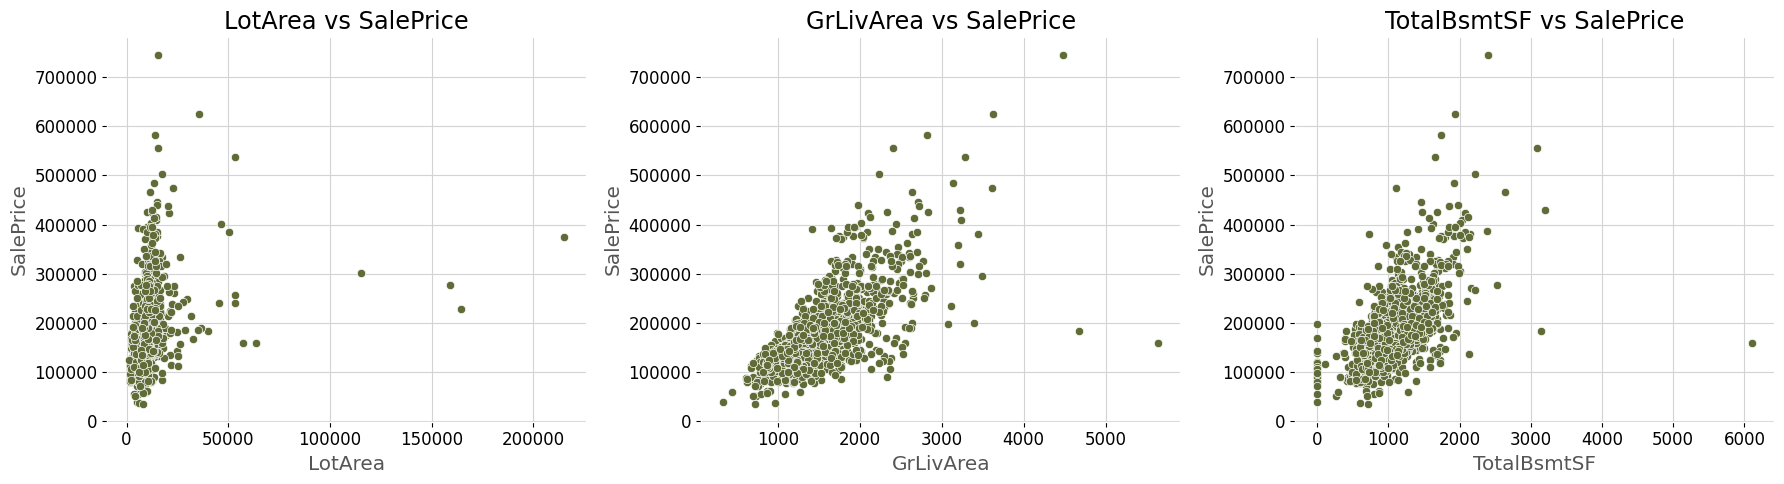

In [22]:
plot_scatter_vs_target(train, ['LotArea','GrLivArea','TotalBsmtSF'], target)

Now we can see more clearly the datas. LotArea is very asymmetrical, but we have no such suspect datas. For these reason I'll apply log on it. For GrLivArea we got two inconssistent datas: 
- GrLivArea ≈ 4500 and SalePrice ≈ 180000
- GrLivArea ≈ 5600 and SalePrice ≈ 160000

And for TotalBsmtSF we got one suspect:
- TotalBsmtSF ≈ 6100 and SalePrice ≈ 160000

We gonna drop this suspects datas.


In [23]:
indices_remover = train[
    (
        (train['GrLivArea'] > 4000) &
        (train['SalePrice'] < 300000)
    )
    |
    (
        train['TotalBsmtSF'] > 5000
    )
].index

train = train.drop(indices_remover)


In [24]:
train['SalePrice'] = np.log1p(train['SalePrice'])
test['SalePrice'] = np.log1p(test['SalePrice'])

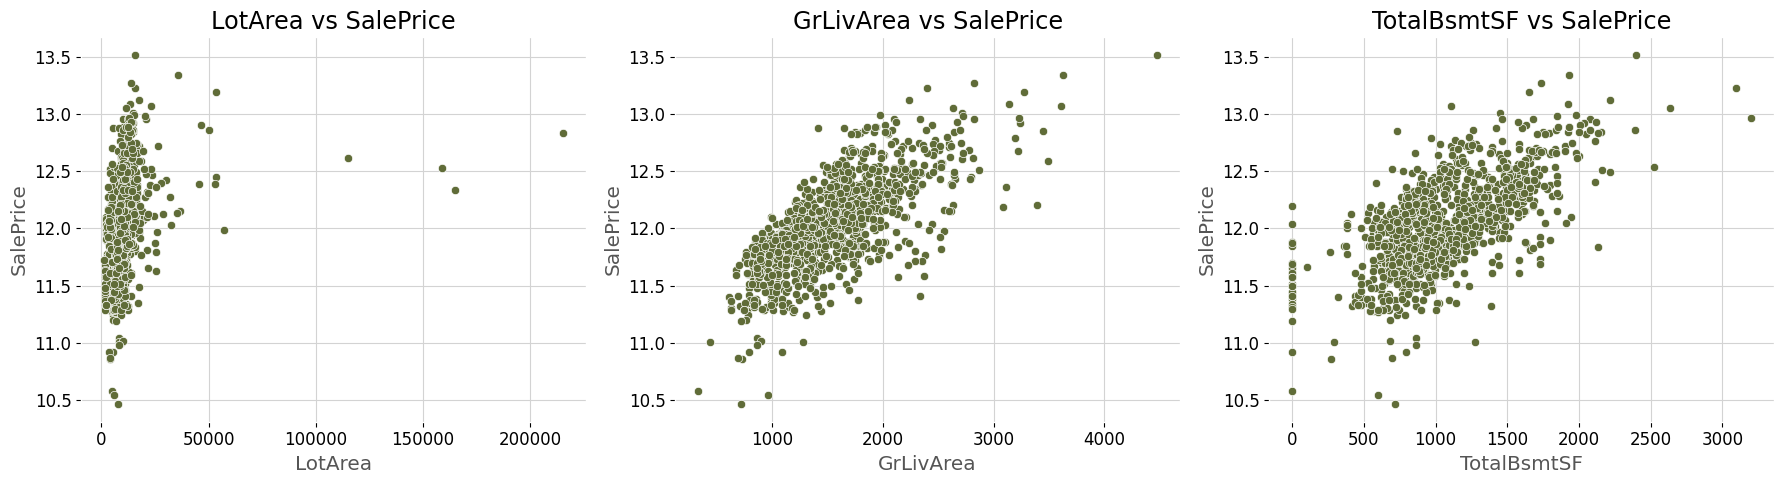

In [25]:
plot_scatter_vs_target(train, ['LotArea','GrLivArea','TotalBsmtSF'], target)

After removing the extreme observations and applying a logarithmic transformation to `SalePrice`, the relationships between the explanatory variables and the target variable became more consistent. The data points exhibit less dispersion, particularly among higher-priced properties, resulting in clearer and more linear patterns.

`GrLivArea` and `TotalBsmtSF` continue to show strong positive relationships with sale price, while `LotArea` remains more variable but does not present any additional observations that warrant removal. Overall, the dataset appears better structured and more suitable for predictive modeling.

### Categorical features distribuction

Now I'll take a look to the categorical features disrtibuction.

In [26]:
set(categorical_features)-set(train.columns)

{'Utilities'}

In [27]:
# Let's remove 'Utilities' from categorical features list
categorical_features = [col for col in categorical_features if col != 'Utilities']

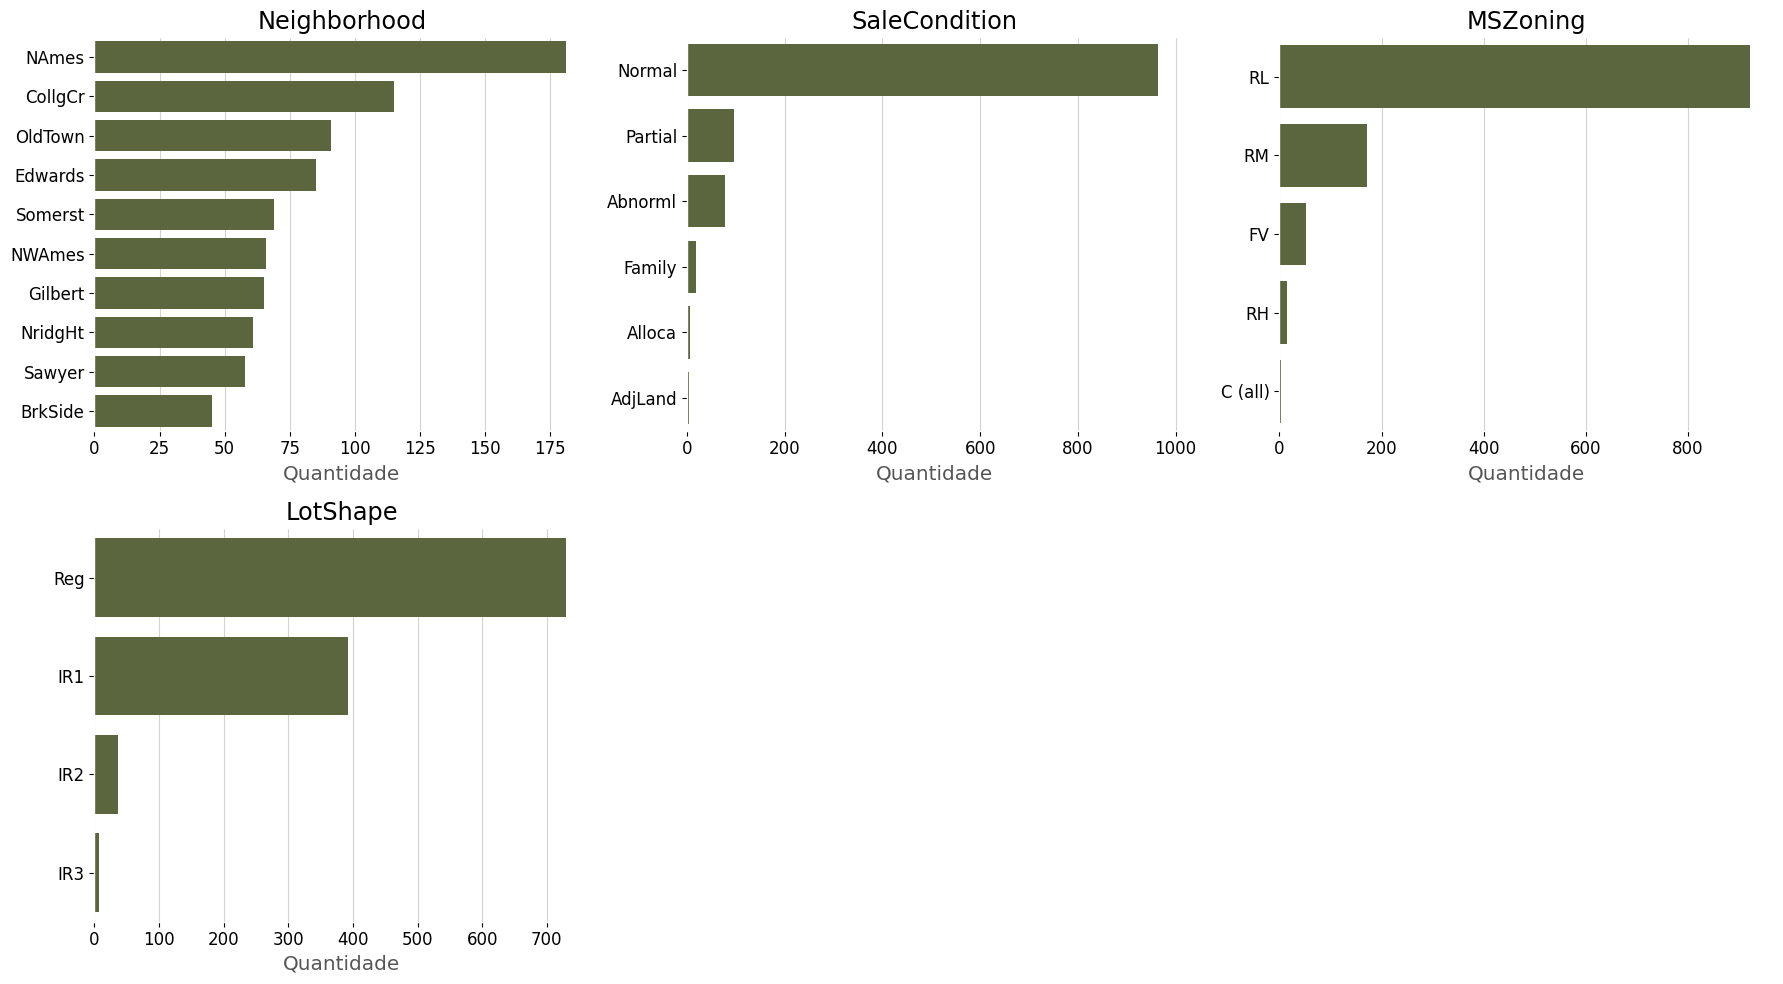

In [28]:
plot_categorical(train, categorical_features)

- **Neighborhood** shows an uneven distribution, with **NAmes** being the most frequent category, followed by **CollgCr** and **OldTown**. This indicates that some neighborhoods are more represented in the dataset.

- **SaleCondition** is highly concentrated in the **Normal** category, which represents most of the sales. The remaining categories have significantly fewer observations, creating potential class imbalance.

- **MSZoning** is strongly dominated by **RL (Residential Low Density)**, while other zoning categories appear less frequently, indicating an imbalance among classes.

- **LotShape** is mainly composed of the **Reg** category, followed by **IR1**, while more irregular lot shapes have fewer observations.



Now i'll see the relationship between SalePrice and Neighborhood.

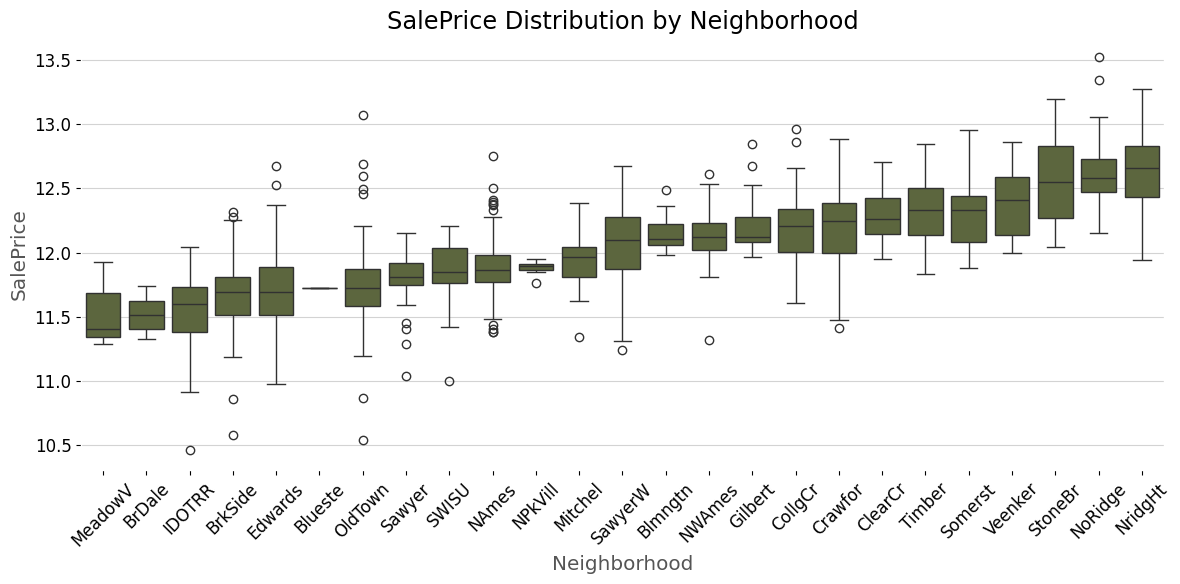

In [29]:
plot_boxplot_target(train,'Neighborhood', target)

### Insights
- **Neighborhood has a strong relationship with SalePrice**, indicating that location is an important factor for property value prediction.

- Higher-priced neighborhoods such as **StoneBr, NridgHt, and NoRidge** show the highest median sale prices, suggesting that properties in these areas tend to be more valuable.

- Neighborhoods like **MeadowV, BrDale, IDOTRR, and Edwards** have lower median prices compared to other areas, indicating regions with more affordable properties.

- Some neighborhoods present a wider price variation (larger box sizes), meaning there is more heterogeneity in property values within the same area.

- Several neighborhoods contain outliers with significantly higher prices, which may represent luxury properties or houses with exceptional characteristics.

- This feature is likely to be highly relevant for the predictive model, especially when combined with variables related to quality, size, and overall condition.

## Bivariate and multivariate analysis
Now i'll do a bivariate and multivariate analysis and try to find how the features are related to each other, and with the target variable.

### Correlation matrix
Let's take a look to the correlation matrix.

In [30]:
corr_matrix=train.corr(numeric_only=True)


In [31]:
corr_matrix['SalePrice'].sort_values(ascending=False)

SalePrice       1.000000
OverallQual     0.813304
GrLivArea       0.719381
GarageCars      0.684979
GarageArea      0.661341
TotalBsmtSF     0.641135
1stFlrSF        0.610058
FullBath        0.585150
YearBuilt       0.577326
YearRemodAdd    0.562651
TotRmsAbvGrd    0.524114
LotArea         0.261227
BedroomAbvGr    0.193334
KitchenAbvGr   -0.157564
Name: SalePrice, dtype: float64

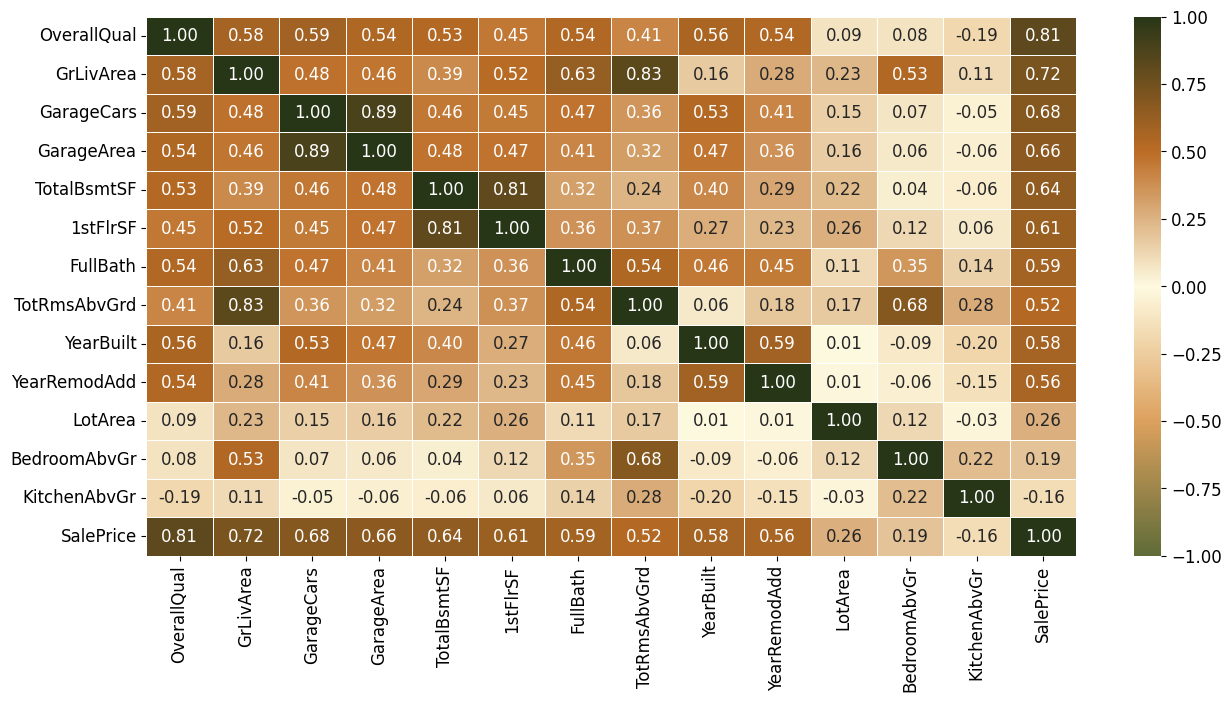

In [ ]:
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_palette",
    custom_palette
)
plt.figure(figsize=(15, 7))
sns.heatmap(corr_matrix, annot=True, cmap=custom_cmap, fmt='.2f', linewidths=0.5,vmax=1, vmin=-1)
plt.show()

### Insights
- **OverallQual** presents the strongest correlation with **SalePrice (0.81)**, indicating that the overall quality of the property is one of the most important factors influencing house prices.

- Size-related features also show strong positive relationships with the target:
  - **GrLivArea (0.72)**: larger living areas tend to be associated with higher property values.
  - **TotalBsmtSF (0.64)** and **1stFlrSF (0.61)**: larger basement and first-floor areas contribute to higher prices.

- Garage-related variables have a strong impact on SalePrice:
  - **GarageCars (0.68)** and **GarageArea (0.66)** suggest that properties with larger garages or more garage capacity generally have higher prices.

- Features related to property age show meaningful correlation:
  - **YearBuilt (0.58)** and **YearRemodAdd (0.56)** indicate that newer or recently remodeled houses tend to have higher market values.

- Some variables show high correlation with each other, suggesting possible **multicollinearity**:
  - **GarageCars and GarageArea (0.89)**
  - **TotalBsmtSF and 1stFlrSF (0.81)**
  - **GrLivArea and TotRmsAbvGrd (0.83)**

- **KitchenAbvGr** has a weak negative correlation with SalePrice (-0.16), suggesting that a higher number of kitchens above ground does not necessarily imply higher property value.

- Overall, the analysis suggests that **quality, living space, garage features, and construction year** are the main numerical factors related to house prices.

Now i'll indentify features with a strong relationship, in order to aviod variables that represent almost the same thing.

In [33]:
high_correlation_pairs(train, threshold=0.8)

,Feature 1,Feature 2,Correlation
0,GarageArea,GarageCars,0.888803
1,1stFlrSF,TotalBsmtSF,0.808400
2,TotRmsAbvGrd,GrLivArea,0.825726
3,SalePrice,OverallQual,0.813304




- A correlation threshold of **0.8** was used to identify highly correlated numerical features.

- The analysis identified the following pairs with high correlation:

  - **GarageArea and GarageCars (0.89)**: both variables represent garage capacity. Since they provide similar information, one of them can be removed to reduce redundancy. **GarageCars** will be kept because it represents garage capacity in a more interpretable way.

  - **1stFlrSF and TotalBsmtSF (0.81)**: both variables represent house area measurements. To avoid redundancy, **TotalBsmtSF** will be kept because basement area can provide additional information about the property.

  - **TotRmsAbvGrd and GrLivArea (0.83)**: both variables are related to the size of the living space. **GrLivArea** will be kept because it directly measures the above-ground living area.

- **OverallQual and SalePrice (0.81)** shows a strong relationship with the target variable. Since this correlation is with the prediction target, this feature will be kept as it is highly relevant for the model.

- Reducing highly correlated variables helps minimize multicollinearity and can improve model stability and interpretability.

In [34]:
drop_features = [
    "GarageArea",
    "1stFlrSF",
    "TotRmsAbvGrd"
]
numerical_features = [col for col in numerical_features if col not in drop_features]
train_model = train.drop(columns=drop_features)


# Data cleaning and preprocessing
To fit machine learning algorithms, it is necessary  to apply some transformations to the data:
- **Missing Values:** The data doesn't have ant missing value, so i'll not be necessary treat them.
- **Outliers:** In the EDA step, I ivestigated and treated the outliers that may represent problemns.
- **Numerical features:** To ensure that numerical features are on a similar scale and more comparable, StandardScaler will be applied. This transformation standardizes the features by centering them around the mean and scaling them according to their standard deviation.
- **Categorical features:** During EDA I decided how to enocoding the categorical features, it will be:
Neighborhood:One Hot Encoding
SaleCondition:One Hot Encoding
MSzoning: One Hot Encoding
LotShape: Ordinal Encoding


Some considerations about EDA:

### Target Variable Transformation
- The target variable **SalePrice** was highly right-skewed, so a logarithmic transformation (`log1p`) was applied to reduce skewness and make the distribution closer to normal.
- This transformation helps improve model performance, especially for regression algorithms.

### Numerical Features Treatment
- Numerical features were analyzed through correlation analysis to identify important variables and potential multicollinearity.
- Features with very high correlation were reviewed to reduce redundancy:
  - **GarageArea** was removed due to high correlation with **GarageCars**.
  - **1stFlrSF** was removed due to high correlation with **TotalBsmtSF**.
  - **TotRmsAbvGrd** was removed due to high correlation with **GrLivArea**.
- StandardScaler was applied to numerical features to standardize their scale and make them more comparable.

### Categorical Features Analysis
- Categorical variables were analyzed using countplots to understand category distribution.
- Features with rare categories were identified and considered for encoding strategies.
- Categorical variables were kept because they may contain important information about property characteristics.

### Feature Selection
- Correlation analysis with SalePrice showed that variables related to:
  - Overall quality
  - Living area
  - Garage features
  - Property age
  
  were among the most relevant predictors.

- The preprocessing decisions were made to reduce redundancy, improve model stability, and preserve the most informative features.

Let's start the preprocessing.

In [35]:
# lets reload test and train data with the problematic features removed
train_model = train.drop(columns=drop_features)
train_model.drop(columns='PriceCategory', inplace=True)
X = train_model.drop("SalePrice", axis=1)
Y = train_model["SalePrice"]
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [36]:
hot_encoded_features=list(filter(lambda x: x!='LotShape', categorical_features))
ordinal_encoded_features=['LotShape']




In [37]:
# remoove target variable from numerical features list
numerical_features = [
    col for col in numerical_features
    if col != "SalePrice"
]
ordinal_pipeline=Pipeline(
    steps=[
        ('ordinal_encoder', OrdinalEncoder()),
        ('std_scaler', StandardScaler())
    ]
)

hot_pipeline=Pipeline(
    steps=[
        ('onehot_encoder', OneHotEncoder(handle_unknown='ignore')),
        ('std_scaler', StandardScaler(with_mean=False))
    ]
)

preprocessor=ColumnTransformer(
    transformers=[
        ('ordinal', ordinal_pipeline, ordinal_encoded_features),
        ('hot', hot_pipeline, hot_encoded_features),
        ('std_scaler', StandardScaler(), numerical_features)
    ]
)

# 06 Model training, comparison, selectioon and tuning
Different regression models will be compared using K-Fold Cross Validation.
Each model will be trained and evaluated using the Root Mean Squared Error (RMSE) metric.

K-Fold Cross Validation is used to provide a more reliable estimate of model performance by training and evaluating the model on different subsets of the data.

In [38]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=10),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

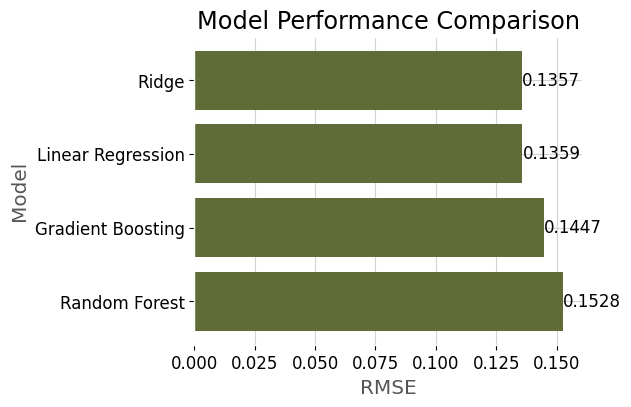

In [39]:
results = compare_models(models, preprocessor, X_train, Y_train)
plot_model_comparison(results)

The models were evaluated using 5-fold cross-validation with Root Mean Squared Error (RMSE) as the evaluation metric. Lower RMSE values indicate better predictive performance.

- Ridge Regression achieved the best performance with the lowest average RMSE (0.1356), slightly outperforming Linear Regression.
- Linear Regression obtained a very similar result, indicating that the relationship between the selected features and the target variable is mostly linear.
- Gradient Boosting and Random Forest showed higher RMSE values, suggesting that the additional complexity of tree-based models did not improve performance on this dataset after preprocessing.
- The small standard deviations across folds indicate consistent model performance.

Let's see a little more tests

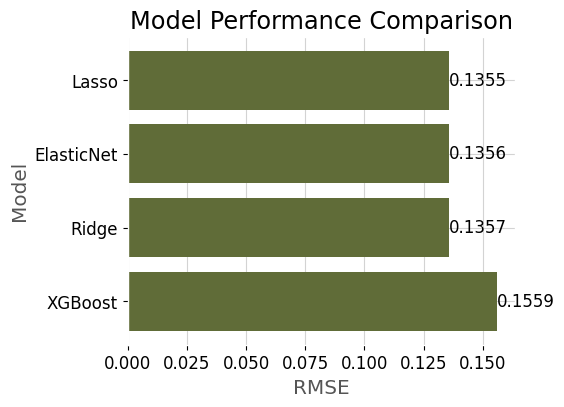

,Model,RMSE Mean,RMSE Std
0,Lasso,0.135532,0.013338
1,ElasticNet,0.135564,0.013309
2,Ridge,0.135652,0.013250
3,XGBoost,0.155854,0.011717


In [40]:
models = {
    "Ridge": Ridge(alpha=10),
    "Lasso": Lasso(alpha=0.0005),
    "ElasticNet": ElasticNet(
        alpha=0.0005,
        l1_ratio=0.9
    ),
    "XGBoost": XGBRegressor(
        random_state=42
    )
}
results = compare_models(models, preprocessor, X_train, Y_train)
plot_model_comparison(results)
results


- Lasso Regression achieved the best performance with the lowest average RMSE (0.1355), slightly outperforming ElasticNet and Ridge.
- ElasticNet and Ridge obtained very similar results, suggesting that regularized linear models are well suited for this dataset.
- The small difference between Lasso, ElasticNet and Ridge indicates that regularization helps control the effect of correlated features and improves generalization.
- XGBoost performed worse than linear models in this experiment, which suggests that the current feature engineering and preprocessing pipeline may favor linear relationships.

Let's apply Lasso with Tuning.

In [41]:
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(max_iter=10000))
    ]
)

In [42]:
# creating alphas
param_grid = {
    "model__alpha": [
        0.00001,
        0.00005,
        0.0001,
        0.0005,
        0.001,
        0.005,
        0.01
    ]
}

# creating kfold cross validation
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
grid_lasso = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)


grid_lasso.fit(
    X_train,
    Y_train
)

# all alphas results
lasso_results = pd.DataFrame(
    grid_lasso.cv_results_
)

lasso_results[
    [
        "param_model__alpha",
        "mean_test_score",
        "std_test_score"
    ]
].sort_values(
    by="mean_test_score",
    ascending=False
)

,param_model__alpha,mean_test_score,std_test_score
4,0.00100,-0.135320,0.013603
3,0.00050,-0.135532,0.013338
2,0.00010,-0.135812,0.013072
1,0.00005,-0.135844,0.013037
0,0.00001,-0.135868,0.013009
5,0.00500,-0.136664,0.014219
6,0.01000,-0.139952,0.014257


In [43]:
# transform score to RMSE
lasso_results["RMSE"] = (
    -lasso_results["mean_test_score"]
)

lasso_results[
    [
        "param_model__alpha",
        "RMSE"
    ]
]

,param_model__alpha,RMSE
0,0.00001,0.135868
1,0.00005,0.135844
2,0.00010,0.135812
3,0.00050,0.135532
4,0.00100,0.135320
5,0.00500,0.136664
6,0.01000,0.139952


In [44]:
print("Best alpha:", grid_lasso.best_params_)

print(
    "Best RMSE:",
    -grid_lasso.best_score_
)

Best alpha: {'model__alpha': 0.001}
Best RMSE: 0.13532010156213994


Now, I'll compare with other models and other metrics to make shure that Lasso is the better option.

In [45]:
models = {
    "Lasso": Pipeline([
        ("preprocess", preprocessor),
        ("model", Lasso(alpha=0.01))
    ]),
    
    "Ridge": Pipeline([
        ("preprocess", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]),
    
    "ElasticNet": Pipeline([
        ("preprocess", preprocessor),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5))
    ])
}
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, Y_train, cv=5, scoring="r2")
    
    results[name] = {
        "R2 médio": scores.mean(),
        "R2 std": scores.std()
    }

results

{'Lasso': {'R2 médio': np.float64(0.8688401279407787),
  'R2 std': np.float64(0.03268752801697767)},
 'Ridge': {'R2 médio': np.float64(0.8783206112355281),
  'R2 std': np.float64(0.025246578340594416)},
 'ElasticNet': {'R2 médio': np.float64(0.8741787420550636),
  'R2 std': np.float64(0.02974394573345913)}}

After training and comparing Lasso, Ridge, and ElasticNet models, **Ridge Regression** was selected as the final model based on a combined analysis of cross-validation and test set performance. In 5-fold cross-validation, Ridge achieved the highest mean R² score (0.8783) and the lowest standard deviation (0.0252), indicating both strong predictive performance and greater stability across different data splits. Although Lasso obtained a slightly lower RMSE on the test set (0.1355 vs. 0.1357 for Ridge), this difference is extremely small and not practically significant, falling within expected statistical noise. Considering the overall consistency between cross-validation and test results, as well as Ridge’s superior stability and generalization performance, it was chosen as the final model. The results also suggest that the problem has a strong linear structure, and that performance differences between linear models are minimal, with Ridge providing the best balance between accuracy and robustness.

# 07 training final model and test. 
Let's train and test our final model

In [46]:
final_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=1.0))
])

final_model.fit(X_train, Y_train)

y_pred = final_model.predict(X_test)

In [47]:
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 0.1175
MAE: 0.0860
R²: 0.9105


The final Ridge Regression model achieved an RMSE of 0.1175 and an MAE of 0.0860, indicating low average prediction errors and good overall accuracy. The R² score of 0.9105 shows that the model is able to explain approximately 91% of the variance in the target variable, demonstrating strong predictive power and effective generalization to unseen data. Overall, these results confirm that the model provides reliable and consistent predictions within the context of the problem.

Let's take a look to real x predict graphic

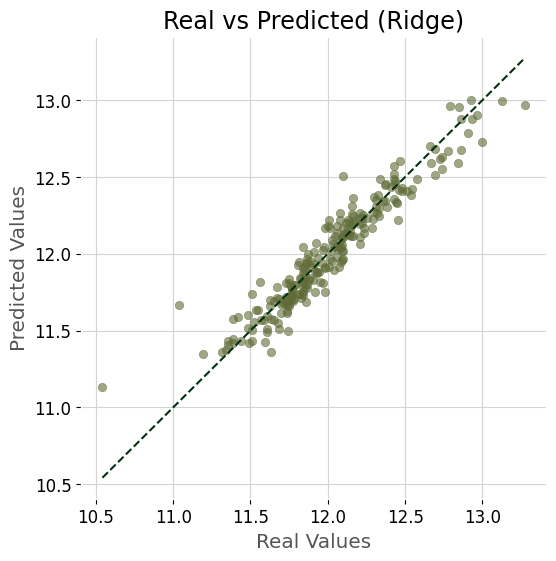

In [48]:
plt.figure(figsize=(6,6))

plt.scatter(Y_test, y_pred, alpha=0.6)

# linha perfeita (y = x)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color="#033011", linestyle='--')

plt.xlabel("Real Values")
plt.ylabel("Predicted Values")
plt.title("Real vs Predicted (Ridge)")
plt.show()

Now, I'll see the residual graphic

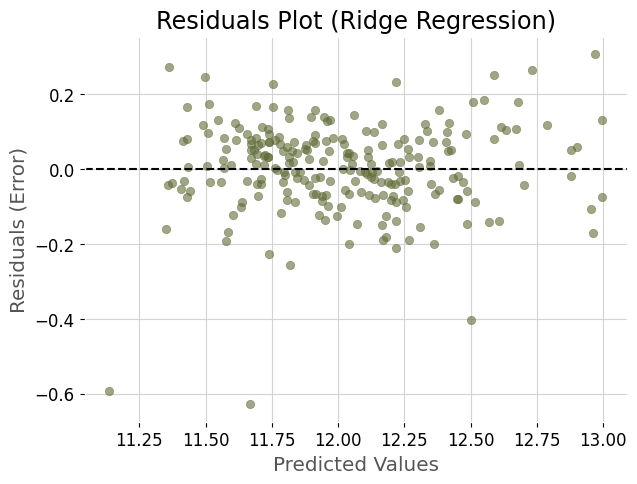

In [49]:
residuals = Y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, color='black', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Error)")
plt.title("Residuals Plot (Ridge Regression)")
plt.show()

- **Strong Indication of Linearity:** The majority of the residuals are randomly and symmetrically scattered around the horizontal reference line ($e = 0$). There are no evident non-linear patterns (such as a U-shape or parabolic trend), confirming that the linear relationship assumed by the Ridge model is appropriate for the data.
- **Consistent Mean Error Close to Zero:** The dense clustering of data points centered directly on the $0.0$ axis demonstrates that the model does not suffer from a systematic bias. On average, the predictions are neither consistently overestimating nor underestimating the target variable.
- **Well-Behaved Homoscedasticity:** Across the primary range of predicted values (between $11.50$ and $12.50$), the spread of the residuals remains relatively constant. The absence of a distinct "fan" or "funnel" shape suggests that the variance of the error terms is stable, satisfying a core assumption of linear regression models.
- **Effective Regularization:** The tight distribution of errors for the bulk of the dataset proves that the Ridge penalty ($\alpha$) successfully managed model complexity and prevented overfitting, resulting in reliable and stable generalized predictions.

*Note: A few isolated outliers are present in the lower bound (negative residuals), which represent specific anomalous cases rather than a structural flaw in the model's overall predictive capability.*

In [50]:
# Saving the model
import joblib

joblib.dump(final_model, "house_price_model.pkl")

['house_price_model.pkl']

#  Final Conclusion

In this project, an exploratory data analysis (EDA) was performed to understand the dataset structure, identify patterns, analyze feature distributions, and investigate relationships between variables and the target variable. The EDA phase helped to detect relevant characteristics of the data, understand the impact of numerical and categorical features, and support the preprocessing and modeling decisions.

After data preparation, feature encoding, and model development, different regression algorithms were evaluated, including Lasso Regression, Ridge Regression, and ElasticNet. Model selection was performed based on cross-validation performance, stability, and final evaluation on unseen test data.

Ridge Regression was selected as the final model due to its better balance between predictive performance and generalization. It achieved the highest cross-validation R² score (0.8783) and the lowest variability among the tested models, indicating greater stability across different data splits. Although Lasso obtained a slightly lower RMSE on the test set, the difference was minimal and not significant enough to outweigh Ridge’s overall consistency.

The final Ridge model achieved an RMSE of 0.1175, an MAE of 0.0860, and an R² score of 0.9105 on the test set. These results indicate that the model explains approximately 91% of the variation in the target variable while maintaining low prediction errors.

The residual analysis showed that the prediction errors are reasonably distributed around zero, suggesting that the model does not present strong bias and provides consistent predictions. Overall, the combination of exploratory data analysis, appropriate preprocessing, model comparison, and validation resulted in a reliable regression model with good accuracy, stability, and generalization capability.